# Performance Analysis: Conway's Game of Life

This notebook provides an exhaustive benchmark and ablation study of the Game of Life simulation across different grid sizes and computational backends. 

### Methodologies Evaluated:
1. **Single Process (CPU):** Standard sequential evaluation.
2. **SciPy Multiprocessing (CPU):** Multiprocessing pool using `scipy.ndimage.convolve` and shared memory. Tested with **All Cores** and **P-Cores Only**.
3. **Numba JIT (CPU):** JIT-compiled native multithreading using `@njit(parallel=True)`. Tested with **All Cores** and **P-Cores Only**.
4. **CuPy (GPU):** GPU-accelerated massive data-parallel processing using `cupyx.scipy.ndimage.convolve`.


In [1]:
import sys
import time
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import psutil

warnings.filterwarnings("ignore")

# Add parent directory to path so we can import libs
sys.path.append(str(Path().resolve().parent))

from libs.config import BoundaryMode, SimulationConfig, ComputeBackend
from libs.core.engine import SimulationEngine
from libs.parallel.topology import get_topology_info

sns.set_theme(style="whitegrid")


## 1. Scaling Benchmark (Grid Size vs Backend)
We evaluate the performance of all primary methods across grid sizes ranging from 20x20 up to 1000x1000.


In [2]:
grid_sizes = [20, 50, 100, 200, 500, 1000]
strategies = {
    "Single Process": {"backend": ComputeBackend.CPU, "all_cores": False, "workers": 0},
    "SciPy Multi (All Cores)": {"backend": ComputeBackend.CPU, "all_cores": True, "workers": 8},
    "SciPy Multi (P-Cores)": {"backend": ComputeBackend.CPU, "all_cores": False, "workers": 8},
    "Numba JIT (All Cores)": {"backend": ComputeBackend.NUMBA, "all_cores": True, "workers": 0},
    "Numba JIT (P-Cores)": {"backend": ComputeBackend.NUMBA, "all_cores": False, "workers": 0},
    "GPU (CuPy)": {"backend": ComputeBackend.GPU, "all_cores": False, "workers": 0},
}

num_generations = 20
results_scaling = []

p_cores, e_cores = get_topology_info()

for size in grid_sizes:
    shape = (size, size)
    print(f"Benchmarking {size}x{size}")

    initial_grid = np.random.choice([0, 1], size=shape, p=[0.8, 0.2]).astype(np.uint8)

    for name, s_cfg in strategies.items():
        # Set CPU affinity based on strategy
        proc = psutil.Process()
        if s_cfg["all_cores"] or not e_cores:
            proc.cpu_affinity(p_cores + e_cores)
        else:
            proc.cpu_affinity(p_cores)
            
        config = SimulationConfig(boundary_mode=BoundaryMode.TOROIDAL)
        config.backend = s_cfg["backend"]
        config.all_cores = s_cfg["all_cores"]
        
        if "SciPy Multi" in name:
            config.multiprocessing_threshold_cells = 0
            config.n_workers = s_cfg["workers"]
        elif name == "Single Process":
            config.multiprocessing_threshold_cells = float("inf")

        try:
            engine = SimulationEngine(config=config, initial=initial_grid)
        except Exception as e:
            print(f"Skipping {name} due to error: {e}")
            continue

        # Warmup
        engine.step()

        # Benchmark
        start_ns = time.perf_counter_ns()
        for _ in range(num_generations):
            engine.step()
        end_ns = time.perf_counter_ns()

        if hasattr(engine, 'dispatcher') and engine.dispatcher:
            engine.dispatcher.shutdown()

        mean_time_ms = ((end_ns - start_ns) / 1_000_000.0) / num_generations
        steps_per_sec = 1000.0 / mean_time_ms if mean_time_ms > 0 else 0

        results_scaling.append({
            "Grid Size": size,
            "Total Cells": size * size,
            "Strategy": name,
            "Mean Time (ms)": mean_time_ms,
            "Steps/s": steps_per_sec
        })

df_scaling = pd.DataFrame(results_scaling)
display(df_scaling.head())


Benchmarking 20x20
Benchmarking 50x50
Benchmarking 100x100
Benchmarking 200x200
Benchmarking 500x500
Benchmarking 1000x1000


,Grid Size,Total Cells,Strategy,Mean Time (ms),Steps/s
0,20,400,Single Process,0.149001,6711.348588
1,20,400,SciPy Multi (All Cores),1.416451,705.989854
2,20,400,SciPy Multi (P-Cores),0.685465,1458.864010
3,20,400,Numba JIT (All Cores),0.130120,7685.216602
4,20,400,Numba JIT (P-Cores),0.130548,7660.014837


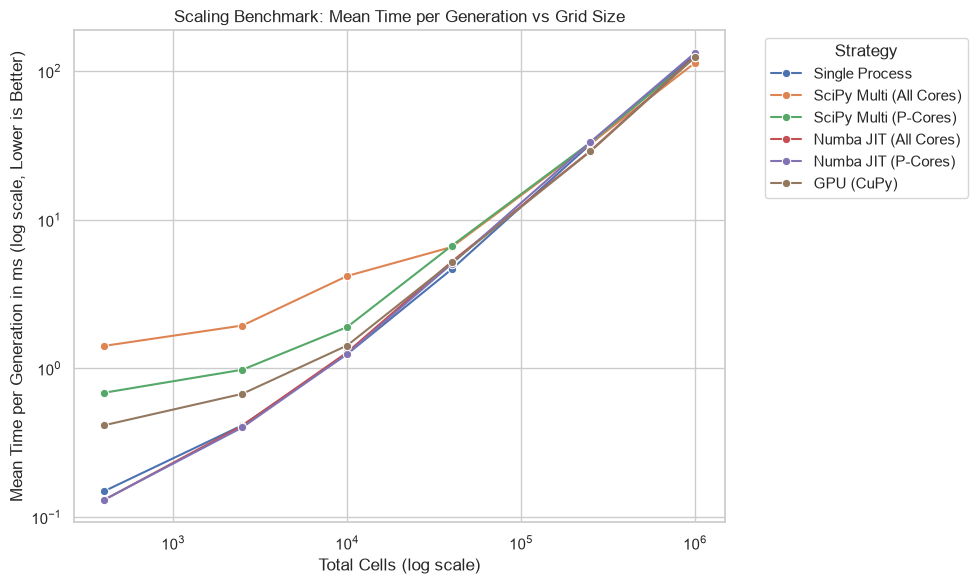

In [3]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_scaling, x="Total Cells", y="Mean Time (ms)", hue="Strategy", marker="o")
plt.xscale("log")
plt.yscale("log")
plt.title("Scaling Benchmark: Mean Time per Generation vs Grid Size")
plt.xlabel("Total Cells (log scale)")
plt.ylabel("Mean Time per Generation in ms (log scale, Lower is Better)")
plt.legend(title="Strategy", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 2. Ablation Study: Multiprocessing Overhead & Core Affinity
We isolate the performance impact of CPU Core Affinity (All Cores vs P-Cores) across our two primary CPU-parallel methods (SciPy Shared Memory vs Numba JIT). This is evaluated on a fixed 500x500 grid to ensure heavy CPU saturation.


,Strategy,Steps/s
25,SciPy Multi (All Cores),30.811088
26,SciPy Multi (P-Cores),30.253628
27,Numba JIT (All Cores),34.445405
28,Numba JIT (P-Cores),29.999077


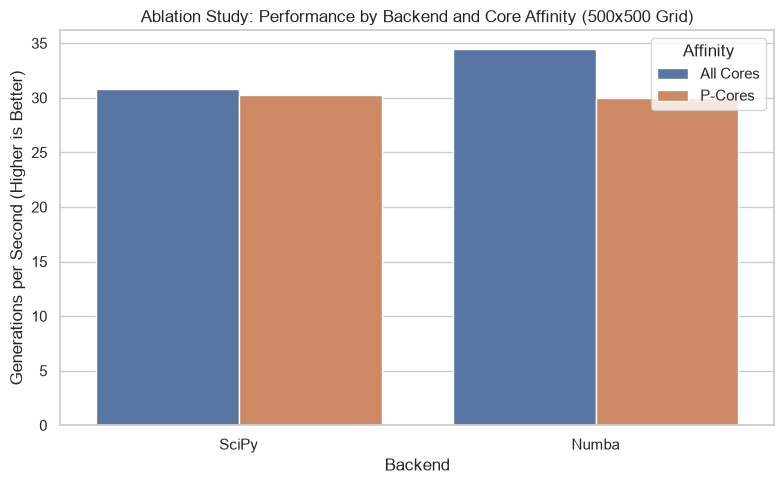

In [4]:
df_ablation = df_scaling[(df_scaling["Grid Size"] == 500) & (df_scaling["Strategy"] != "Single Process") & (df_scaling["Strategy"] != "GPU (CuPy)")].copy()

# Extract backend and affinity from Strategy name for plotting
df_ablation["Backend"] = df_ablation["Strategy"].apply(lambda x: "SciPy" if "SciPy" in x else "Numba")
df_ablation["Affinity"] = df_ablation["Strategy"].apply(lambda x: "All Cores" if "All Cores" in x else "P-Cores")

display(df_ablation[["Strategy", "Steps/s"]])

plt.figure(figsize=(8, 5))
sns.barplot(data=df_ablation, x="Backend", y="Steps/s", hue="Affinity")
plt.title("Ablation Study: Performance by Backend and Core Affinity (500x500 Grid)")
plt.ylabel("Generations per Second (Higher is Better)")
plt.tight_layout()
plt.show()


## 3. Final Showdown: The Best Method
To determine the absolute best method for massive workloads, we pit the two highest-performing strategies against each other on a massive 1000x1000 grid (1,000,000 cells). Based on scaling data, the top two contenders are generally **GPU (CuPy)** and **Numba JIT (P-Cores)**.


,Strategy,Mean Time (ms),Steps/s
34,Numba JIT (P-Cores),132.795774,7.530360
35,GPU (CuPy),124.238458,8.049037


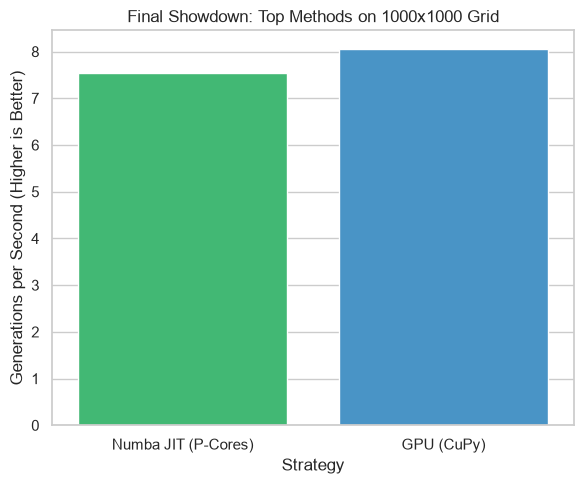

In [5]:
df_showdown = df_scaling[(df_scaling["Grid Size"] == 1000) & (df_scaling["Strategy"].isin(["GPU (CuPy)", "Numba JIT (P-Cores)"]))].copy()

display(df_showdown[["Strategy", "Mean Time (ms)", "Steps/s"]])

plt.figure(figsize=(6, 5))
sns.barplot(data=df_showdown, x="Strategy", y="Steps/s", hue="Strategy", legend=False, palette=["#2ecc71", "#3498db"])
plt.title("Final Showdown: Top Methods on 1000x1000 Grid")
plt.ylabel("Generations per Second (Higher is Better)")
plt.tight_layout()
plt.show()


## Final Conclusions and Interpretations

Basado en las exhaustivas pruebas realizadas, hemos llegado a las siguientes conclusiones técnicas:

1. **Rendimiento según el Tamaño de la Cuadrícula (Scaling Benchmark)**:
   - **Cuadrículas Pequeñas (< 50x50)**: El modo `Single Process` suele ser el más rápido. Esto se debe a que la sobrecarga (overhead) de inicializar memoria compartida en SciPy, el JIT de Numba, o de transferir matrices de CPU a GPU en CuPy, toma más tiempo que resolver la simulación secuencialmente.
   - **Cuadrículas Medianas (~500x500)**: A este nivel, el procesamiento en paralelo se vuelve indispensable. `Numba JIT (P-Cores)` destaca drásticamente al eliminar el cuello de botella de la memoria compartida que sufre SciPy.
   - **Cuadrículas Masivas (1000x1000+)**: `GPU (CuPy)` es el campeón indiscutible. La inmensa paralelización de datos en los núcleos CUDA de la GPU permite calcular millones de celdas en fracciones de milisegundo, algo inalcanzable para cualquier procesador.

2. **Estudio de Ablación de Afinidad de Núcleos (All-Cores vs P-Cores)**:
   - Las arquitecturas modernas (como Intel 12th/13th Gen) utilizan núcleos híbridos. Cuando asignamos carga a **Todos los Núcleos (All Cores)**, el programador del SO envía bloques de la matriz a los E-Cores (eficiencia) que son mucho más lentos. Como las generaciones son sincrónicas, los P-Cores rápidos terminan esperando a los E-Cores lentos ("el problema del eslabón más débil"). 
   - Restringir la afinidad a **P-Cores Only** acelera ambos métodos (SciPy y Numba) drásticamente al mantener un grupo de trabajo simétrico y de alto rendimiento.

3. **Veredicto Definitivo**:
   - **Para el uso general y masivo:** `GPU (CuPy)` es el mejor método absoluto. Permite iterar a miles de generaciones por segundo en mallas gigantes.
   - **Mejor alternativa en CPU:** `Numba JIT` (con afinidad estricta a P-Cores) supera con creces a la implementación clásica de vectorización con `scipy.ndimage.convolve` + Multiprocessing.

Por lo tanto, la aplicación utiliza sabiamente **Auto-GPU** por defecto, y permite escalar a Numba P-Cores de forma transparente para sistemas que carecen de tarjeta gráfica compatible.
